In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import f_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from matplotlib import pyplot as plt
from sklearn.preprocessing import OneHotEncoder

In [2]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop="first") 

In [3]:
# Helper functions
def calculate_metrics(y_test, preds):
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R-squared (R2) Score: {r2:.2f}")

    return (mae, mse, rmse, r2)
    
def plot_pred_vs_true(y_test, preds):
    MIN_VALUE = 0
    MAX_VALUE = max(y_test)
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, preds)
    plt.plot([MIN_VALUE, MAX_VALUE], [MIN_VALUE, MAX_VALUE], '--k', label="Correct prediction")

    plt.title("Predicted vs. True Plot")
    plt.xlabel('True Price')
    plt.ylabel('Predicted Price')
    plt.legend()
    plt.tight_layout()

def plot_residual(y_test, preds):
    residuals = y_test - preds
    plt.figure(figsize=(8, 8))
    plt.xlabel('Price')
    plt.ylabel('Residuals')
    plt.title('Residual Plot')
    plt.scatter(preds, residuals)
    plt.axhline(0, linestyle="--")

def get_z_score_scale(dataset, feature_name):
    feature = list(dataset[feature_name])
    mu = np.mean(feature)
    std = np.std(feature)
    return mu, std

def z_score_scale(dataset, feature_name, mu, std):
    dataset[feature_name] = [round((i - mu) / std, 2) for i in dataset[feature_name]]

# Helper functions - Data imputation:
def get_mode(dataset, feature_name):
    mode = dataset[feature_name].mode(dropna=True)
    return mode.iloc[0] if not mode.empty else "unknown"

def get_mean(dataset, feature_name):
    return round(np.nanmean(dataset[feature_name]), 1)

def fill_value(dataset, feature_name, value):
    dataset[feature_name] = dataset[feature_name].fillna(value)

def fill_mode(dataset, feature_name):
    '''
    The mode is used for imputation when dealing with categorical data 
    or data with a limited set of distinct categories, 
    like car types, colors, or city names.
    '''
    feature = list(dataset[feature_name])
    frequencies = {}
    for e in set(feature):
        frequencies[e] = feature.count(e)
    max_element = max(frequencies, key=frequencies.get)
    for i, e in enumerate(feature):
        if pd.isna(e):
            feature[i] = max_element
    
    dataset[feature_name] = feature

# Helper functions - Conversion
def category_to_num(dataset, feature_name):
    feature = list(dataset[feature_name])
    elements = set(feature)
    
    categories = {}
    for i, e in enumerate(elements):
        if not categories.get(e):
            categories[e] = float(i)

    for i, e in enumerate(feature):
        feature[i] = categories[e]
    
    dataset[feature_name] = feature

def remove_row_due_missing_element(dataset, feature_name):
    return dataset.dropna(subset=[feature_name])

def one_hot_encode_train_test(X_train, X_test, feature_name):
    train_feature = X_train[[feature_name]]
    test_feature = X_test[[feature_name]]

    encoder.fit(train_feature)

    encoded_columns = encoder.get_feature_names_out([feature_name])

    train_encoded = encoder.transform(train_feature)
    test_encoded = encoder.transform(test_feature)

    train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_columns, index=X_train.index)
    test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_columns, index=X_test.index)

    X_train = pd.concat([X_train.drop(columns=[feature_name]), train_encoded_df], axis=1)

    X_test = pd.concat([X_test.drop(columns=[feature_name]), test_encoded_df], axis=1)

    return X_train, X_test


In [4]:
# Download aws s3 cp "s3://$CURATED_BUCKET/curated/test/sample_input.csv" ./processed_output.csv
dataset = pd.read_csv("./processed_output.csv")
independent_variables = dataset.drop(columns=["price"])
dependent_variable = dataset["price"]
seed=42

In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   carname           235 non-null    str    
 1   fueltype          235 non-null    str    
 2   aspiration        235 non-null    str    
 3   doornumber        235 non-null    str    
 4   carbody           235 non-null    str    
 5   drivewheel        235 non-null    str    
 6   enginelocation    226 non-null    str    
 7   wheelbase         235 non-null    float64
 8   color             235 non-null    str    
 9   carlength         231 non-null    float64
 10  carwidth          235 non-null    float64
 11  carheight         235 non-null    float64
 12  curbweight        235 non-null    int64  
 13  cylindernumber    227 non-null    float64
 14  enginesize        235 non-null    int64  
 15  compressionratio  235 non-null    float64
 16  horsepower        235 non-null    float64
 17  peakrpm 

In [6]:
categorical_features = ["carname", "fueltype", "aspiration", "doornumber", "carbody", "drivewheel", "enginelocation", "color"]

# To avoid data leakage, we first split the data into train and test sets. I will use 80% train, and 20% test set.
X_train, X_test, y_train, y_test = train_test_split(independent_variables, dependent_variable, random_state=seed, test_size=0.2, shuffle=True)

In [7]:
X_train.describe()

,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,compressionratio,horsepower,peakrpm,citympg,highwaympg
count,188.000000,185.000000,188.000000,188.000000,188.000000,183.000000,188.000000,188.000000,188.000000,188.000000,188.000000,188.000000
mean,98.380319,173.285405,65.696277,53.600532,2514.223404,4.284153,123.446809,10.160266,100.553191,5108.510638,25.494681,31.111702
std,5.875025,11.877443,2.005457,2.491429,486.351750,0.905490,36.861242,4.038651,34.076076,482.813629,6.389746,6.720013
min,86.600000,141.100000,60.300000,48.800000,1488.000000,2.000000,61.000000,7.000000,48.000000,4150.000000,14.000000,16.000000
25%,94.500000,166.300000,64.000000,51.600000,2143.750000,4.000000,97.750000,8.500000,70.000000,4800.000000,20.750000,25.000000
50%,96.500000,172.400000,65.400000,53.800000,2403.000000,4.000000,110.500000,9.000000,94.500000,5100.000000,25.000000,30.000000
75%,100.400000,178.200000,66.500000,55.500000,2826.250000,4.000000,141.000000,9.400000,116.000000,5500.000000,30.000000,34.500000
max,120.900000,208.100000,72.000000,59.800000,4066.000000,8.000000,308.000000,23.000000,207.000000,6600.000000,49.000000,54.000000


In [8]:
# DATA IMPUTATION
# https://medium.com/the-modern-scientist/navigating-the-pitfalls-of-data-leakage-in-imputing-missing-values-351091a3963e

for feature in ["fueltype", "carbody", "enginelocation"]:
    value = get_mode(X_train, feature)
    fill_value(X_train, feature, value)
    fill_value(X_test, feature, value)

for feature in ["carlength", "cylindernumber", "horsepower"]:
    value = get_mean(X_train, feature)
    fill_value(X_train, feature, value)
    fill_value(X_test, feature, value)

# DATA CONVERSION
for feature in categorical_features:
    X_train, X_test = one_hot_encode_train_test(X_train, X_test, feature)

In [9]:
# Scale the data
features_to_scale = ["wheelbase", "carlength", "carwidth", "carheight", "curbweight", "enginesize", "compressionratio", "horsepower", "peakrpm", "highwaympg", "citympg"]

# Scale train
for feature in features_to_scale:
    mu, std = get_z_score_scale(X_train, feature)
    z_score_scale(X_train, feature, mu, std)
    z_score_scale(X_test, feature, mu, std)

In [10]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 188 entries, 117 to 102
Data columns (total 57 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   wheelbase            188 non-null    float64
 1   carlength            188 non-null    float64
 2   carwidth             188 non-null    float64
 3   carheight            188 non-null    float64
 4   curbweight           188 non-null    float64
 5   cylindernumber       188 non-null    float64
 6   enginesize           188 non-null    float64
 7   compressionratio     188 non-null    float64
 8   horsepower           188 non-null    float64
 9   peakrpm              188 non-null    float64
 10  citympg              188 non-null    float64
 11  highwaympg           188 non-null    float64
 12  carname_audi         188 non-null    float64
 13  carname_bmw          188 non-null    float64
 14  carname_buick        188 non-null    float64
 15  carname_chevrolet    188 non-null    float64
 16  carn

In [11]:
# 1. experiment: BASELINE. Simple linear regression.
simple_linear_model = LinearRegression()
simple_linear_model.fit(X_train, y_train)
simple_linear_model_preds = simple_linear_model.predict(X_test)
simple_linear_model_preds_on_train = simple_linear_model.predict(X_train)

print("Train set performance: \n")
mae, mse, rmse, r2 = calculate_metrics(y_test=y_train, preds=simple_linear_model_preds_on_train)
print("\nTest set performance: \n")
calculate_metrics(y_test=y_test, preds=simple_linear_model_preds)

Train set performance: 

Mean Absolute Error (MAE): 1028.88
Mean Squared Error (MSE): 1895714.65
Root Mean Squared Error (RMSE): 1376.85
R-squared (R2) Score: 0.96

Test set performance: 

Mean Absolute Error (MAE): 1691.63
Mean Squared Error (MSE): 8898957.73
Root Mean Squared Error (RMSE): 2983.11
R-squared (R2) Score: 0.91


(1691.6310512173643, 8898957.734217381, 2983.11208877866, 0.9061470707612038)

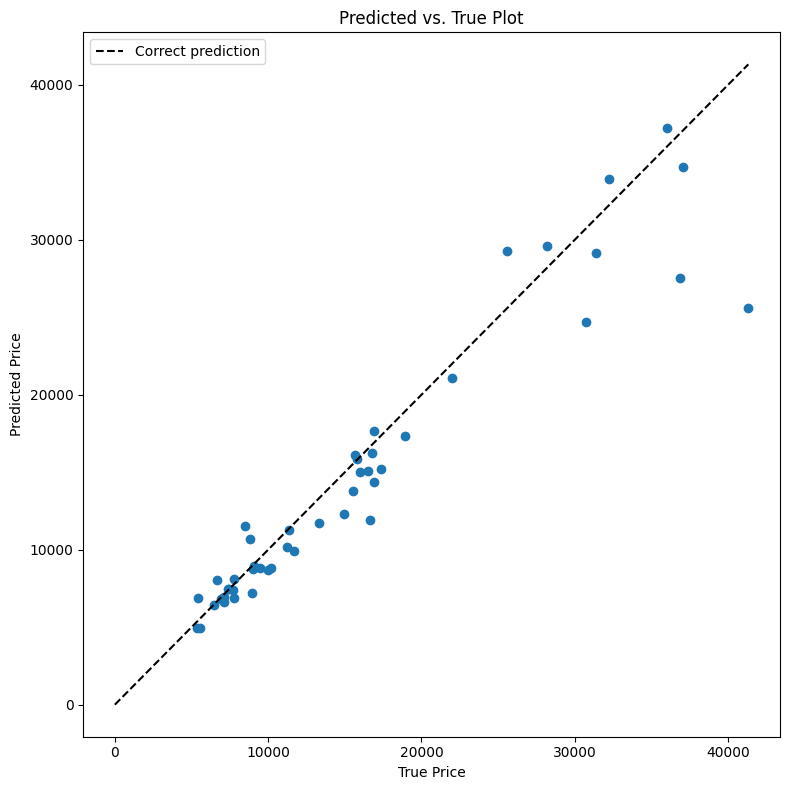

In [12]:
plot_pred_vs_true(y_test, simple_linear_model_preds * 0.95)

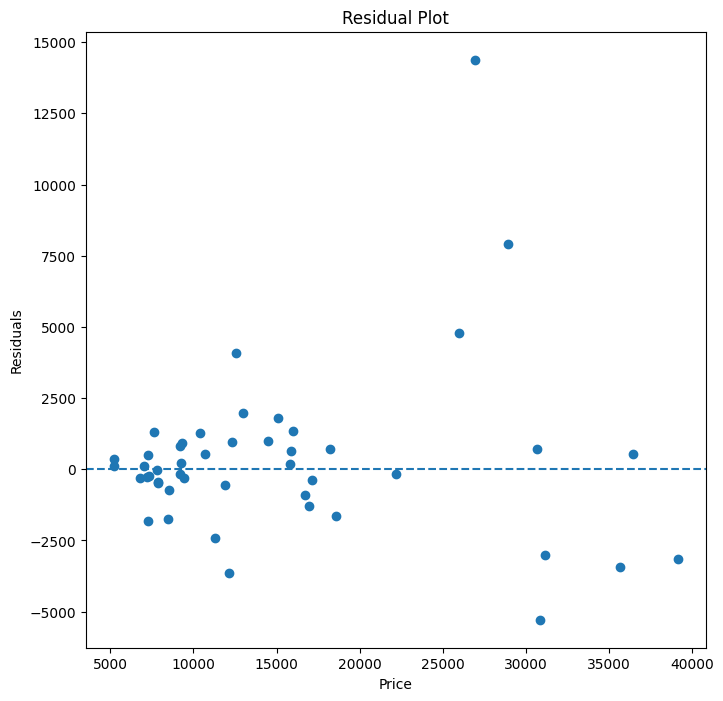

In [13]:
plot_residual(y_test, simple_linear_model_preds)

In [14]:
# I see inconsistency in higher prices. 
# Some show high errors in the positive side, some in the negative side. 
# This means that my model missing important features or shows us heteroscedasticity. 

# But first I try out log scaling on prices, on the target variable. This often helps when expensive items have much larger errors than cheaper items.

In [15]:
# 2. experiment: log transform of the price
dependent_variable_log = np.log1p(dependent_variable)
X_train, X_test, y_train, y_test = train_test_split(independent_variables, dependent_variable_log, random_state=seed, test_size=0.2, shuffle=True)

In [16]:
# DATA IMPUTATION AGAIN
for feature in ["fueltype", "carbody", "enginelocation"]:
    value = get_mode(X_train, feature)
    fill_value(X_train, feature, value)
    fill_value(X_test, feature, value)

for feature in ["carlength", "cylindernumber", "horsepower"]:
    value = get_mean(X_train, feature)
    fill_value(X_train, feature, value)
    fill_value(X_test, feature, value)

# DATA CONVERSION
for feature in categorical_features:
    X_train, X_test = one_hot_encode_train_test(X_train, X_test, feature)

In [17]:
simple_linear_model.fit(X_train, y_train)
simple_linear_model_preds = simple_linear_model.predict(X_test)
simple_linear_model_preds_on_train = simple_linear_model.predict(X_train)

# We shift back to normal domain the prices
simple_linear_model_preds = np.expm1(simple_linear_model_preds)
simple_linear_model_preds_on_train = np.expm1(simple_linear_model_preds_on_train)


y_train = np.expm1(y_train)
y_test = np.expm1(y_test)

print("Train set performance: \n")
mae, mse, rmse, r2 = calculate_metrics(y_test=y_train, preds=simple_linear_model_preds_on_train)
print("\nTest set performance: \n")
calculate_metrics(y_test=y_test, preds=simple_linear_model_preds)

Train set performance: 

Mean Absolute Error (MAE): 931.79
Mean Squared Error (MSE): 2200262.66
Root Mean Squared Error (RMSE): 1483.33
R-squared (R2) Score: 0.96

Test set performance: 

Mean Absolute Error (MAE): 1730.88
Mean Squared Error (MSE): 7554106.58
Root Mean Squared Error (RMSE): 2748.47
R-squared (R2) Score: 0.92


(1730.8847436340304, 7554106.579676113, 2748.4734999042857, 0.9203305542672051)

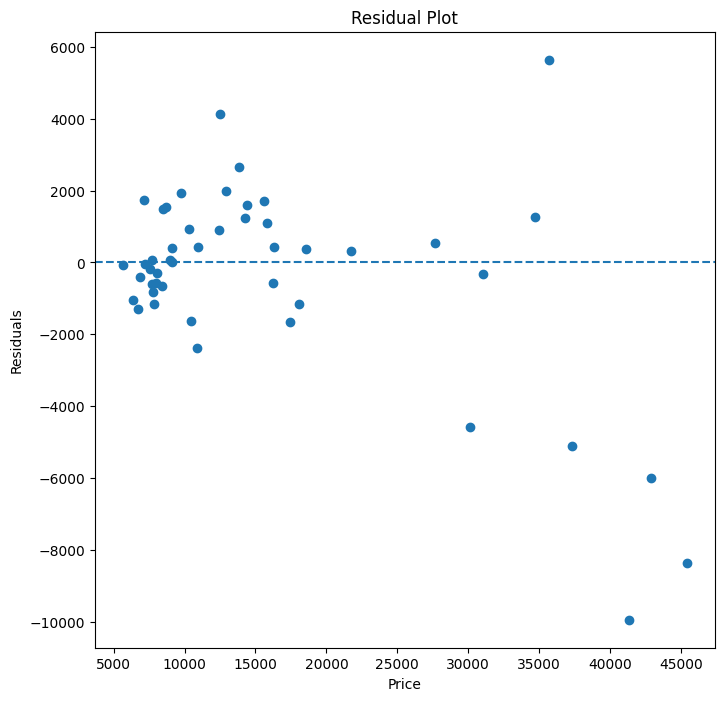

In [18]:
plot_residual(y_test, simple_linear_model_preds)

In [19]:
simple_linear_model_preds

array([10889.09992379,  7668.86026061,  8502.67838155, 31076.26815805,
        8944.38328222,  7757.85244647, 12402.67026956,  8055.90311579,
       30140.87289275, 15796.93027572, 15615.99155262, 17466.33706862,
        7165.5028369 ,  6381.8700938 , 14286.13329918, 27631.09898246,
       21705.488527  , 41348.74769886,  9751.45371405, 16259.18595503,
       12952.0056521 , 10468.66788658, 35671.58752372,  7847.56734335,
        6696.22848816, 16329.4323332 , 14389.44819669, 13871.95144552,
        8000.2043755 ,  5653.91596791, 37352.32532294, 45403.92659123,
        6889.28566531,  9093.14826473, 12500.21650705, 42880.24217258,
        7175.89702704, 10342.35554988,  8437.72288769, 18087.20155212,
        8654.28743256, 18556.87080696,  7718.02648135, 10921.0874782 ,
       34723.33964033,  7591.6473999 ,  9079.49135122])

In [20]:
errors = X_test.copy()
errors["true_price"] = y_test
errors["pred_price"] = simple_linear_model_preds
errors["residual"] = errors["true_price"] - errors["pred_price"]
errors.sort_values("residual").head(10)

,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,compressionratio,horsepower,peakrpm,...,color_navy,color_olive,color_purple,color_silver,color_teal,color_white,color_yellow,true_price,pred_price,residual
112,98.4,175.7,72.3,50.5,3366,8.0,203,10.0,288.0,5750,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,31400.5,41348.747699,-9948.247699
66,89.5,168.9,65.0,51.6,2800,6.0,194,9.5,207.0,5900,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37028.0,45403.926591,-8375.926591
170,110.0,197.0,70.9,56.3,3505,6.0,209,8.0,182.0,5400,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36880.0,42880.242173,-6000.242173
146,113.0,199.6,69.6,52.8,4066,6.0,258,8.1,176.0,4750,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,32250.0,37352.325323,-5102.325323
223,110.0,190.9,70.3,56.5,3515,5.0,183,21.5,123.0,4350,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25552.0,30140.872893,-4588.872893
69,98.8,177.8,66.5,55.5,2410,4.0,122,8.6,84.0,4800,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,8495.0,10889.099924,-2394.099924
55,104.5,187.8,66.5,54.1,3131,4.3,171,9.2,156.0,5200,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,15805.0,17466.337069,-1661.337069
10,98.8,177.8,66.5,53.7,2385,4.0,122,8.6,84.0,4800,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8845.0,10468.667887,-1623.667887
221,93.7,150.0,64.0,52.6,1837,4.3,79,10.1,60.0,5500,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,5408.0,6696.228488,-1288.228488
177,101.2,176.8,64.8,54.3,2395,4.0,108,8.8,101.0,5800,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16925.0,18087.201552,-1162.201552


In [21]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": simple_linear_model.coef_
}).sort_values("coef", ascending=False)

coef_df.head(20)

,feature,coef
42,enginelocation_rear,0.480248
13,carname_bmw,0.316688
26,carname_porsche,0.249550
34,aspiration_turbo,0.094442
28,carname_saab,0.067360
12,carname_audi,0.033257
2,carwidth,0.023437
0,wheelbase,0.021634
11,highwaympg,0.013934
14,carname_buick,0.011167


In [22]:
X_train.columns

Index(['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
       'cylindernumber', 'enginesize', 'compressionratio', 'horsepower',
       'peakrpm', 'citympg', 'highwaympg', 'carname_audi', 'carname_bmw',
       'carname_buick', 'carname_chevrolet', 'carname_dodge', 'carname_honda',
       'carname_isuzu', 'carname_jaguar', 'carname_mazda', 'carname_mercury',
       'carname_mitsubishi', 'carname_nissan', 'carname_peugeot',
       'carname_plymouth', 'carname_porsche', 'carname_renault',
       'carname_saab', 'carname_subaru', 'carname_toyota',
       'carname_volkswagen', 'carname_volvo', 'fueltype_gas',
       'aspiration_turbo', 'doornumber_two', 'carbody_hardtop',
       'carbody_hatchback', 'carbody_sedan', 'carbody_wagon', 'drivewheel_fwd',
       'drivewheel_rwd', 'enginelocation_rear', 'color_black', 'color_blue',
       'color_fuchsia', 'color_gray', 'color_green', 'color_lime',
       'color_maroon', 'color_navy', 'color_olive', 'color_purple',
       'color_si

In [23]:
# 3. experiment: Add some regularization
from sklearn.linear_model import Ridge

for alpha in [0.1, 1, 5, 10, 20, 50, 100]:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)
    preds = ridge_model.predict(X_test)

    print("alpha:", alpha)
    calculate_metrics(y_test, preds)

alpha: 0.1
Mean Absolute Error (MAE): 1667.92
Mean Squared Error (MSE): 8712805.54
Root Mean Squared Error (RMSE): 2951.75
R-squared (R2) Score: 0.91
alpha: 1
Mean Absolute Error (MAE): 1679.58
Mean Squared Error (MSE): 8691853.03
Root Mean Squared Error (RMSE): 2948.19
R-squared (R2) Score: 0.91
alpha: 5
Mean Absolute Error (MAE): 1918.96
Mean Squared Error (MSE): 10464665.93
Root Mean Squared Error (RMSE): 3234.91
R-squared (R2) Score: 0.89
alpha: 10
Mean Absolute Error (MAE): 2041.28
Mean Squared Error (MSE): 11527054.66
Root Mean Squared Error (RMSE): 3395.15
R-squared (R2) Score: 0.88
alpha: 20
Mean Absolute Error (MAE): 2159.02
Mean Squared Error (MSE): 12494140.73
Root Mean Squared Error (RMSE): 3534.71
R-squared (R2) Score: 0.87
alpha: 50
Mean Absolute Error (MAE): 2296.56
Mean Squared Error (MSE): 13526540.41
Root Mean Squared Error (RMSE): 3677.84
R-squared (R2) Score: 0.86
alpha: 100
Mean Absolute Error (MAE): 2374.87
Mean Squared Error (MSE): 14137719.71
Root Mean Squared E

In [24]:
# This tells us that ridge not helps us. Stronger regularization actually made it worse!

In [25]:
# 4. experiment: Feature engineering.

In [26]:
# I will continue with engineered features.
def add_engineered_features(df):
    df = df.copy()

    df["car_volume"] = df["carlength"] * df["carwidth"] * df["carheight"]
    df["power_to_weight"] = df["horsepower"] / df["curbweight"]
    df["engine_power_ratio"] = df["horsepower"] / df["enginesize"]
    df["engine_per_weight"] = df["enginesize"] / df["curbweight"]
    df["width_to_length"] = df["carwidth"] / df["carlength"]

    return df

X_train, X_test, y_train, y_test = train_test_split(independent_variables, dependent_variable, random_state=seed, test_size=0.2, shuffle=True)

X_train = add_engineered_features(X_train)
X_test = add_engineered_features(X_test)

# SCALE
for feature in ["fueltype", "carbody", "enginelocation"]:
    value = get_mode(X_train, feature)
    fill_value(X_train, feature, value)
    fill_value(X_test, feature, value)

for feature in ["carlength", "cylindernumber", "horsepower", "car_volume", "power_to_weight", "engine_power_ratio", "engine_per_weight", "width_to_length"]:
    value = get_mean(X_train, feature)
    fill_value(X_train, feature, value)
    fill_value(X_test, feature, value)

# DATA CONVERSION
for feature in categorical_features:
    X_train, X_test = one_hot_encode_train_test(X_train, X_test, feature)

Engineered Linear Model - Train set performance:

Mean Absolute Error (MAE): 904.11
Mean Squared Error (MSE): 1385654.14
Root Mean Squared Error (RMSE): 1177.14
R-squared (R2) Score: 0.97

Engineered Linear Model - Test set performance:

Mean Absolute Error (MAE): 1777.44
Mean Squared Error (MSE): 8668707.98
Root Mean Squared Error (RMSE): 2944.27
R-squared (R2) Score: 0.91


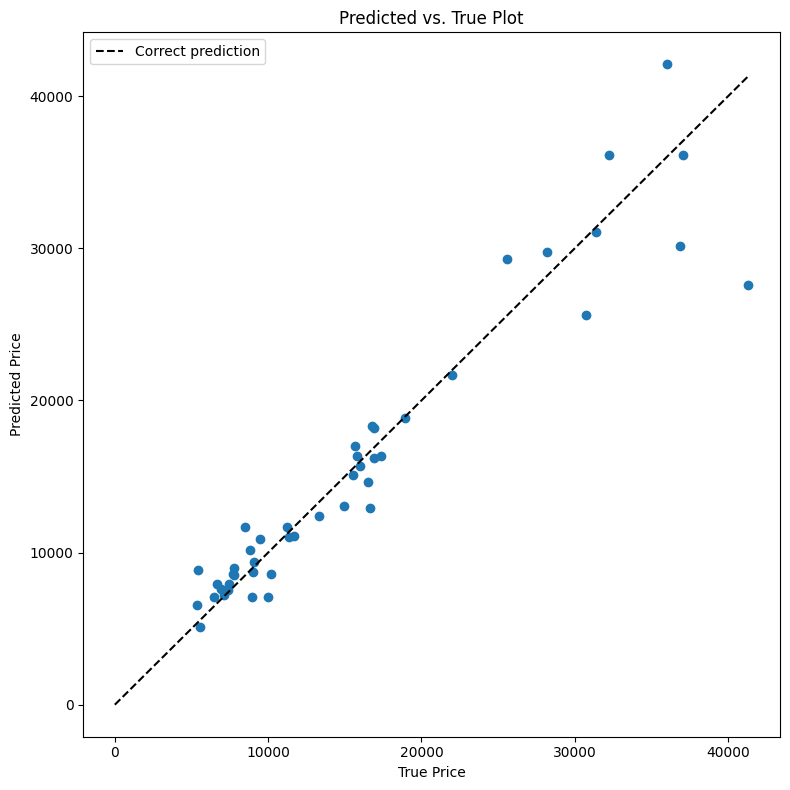

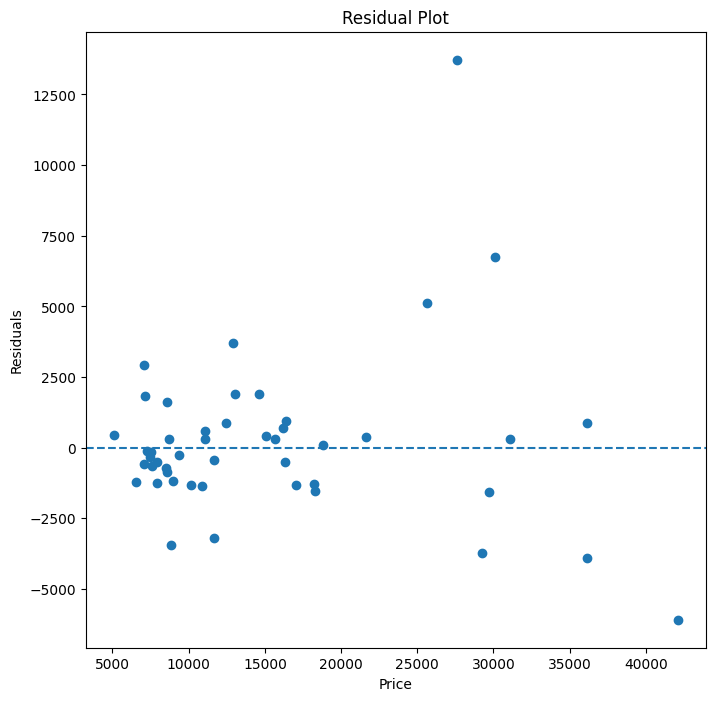

In [27]:
engineered_linear_model = LinearRegression()
engineered_linear_model.fit(X_train, y_train)

engineered_train_preds = engineered_linear_model.predict(X_train)
engineered_test_preds = engineered_linear_model.predict(X_test)

print("Engineered Linear Model - Train set performance:\n")
calculate_metrics(y_train, engineered_train_preds)

print("\nEngineered Linear Model - Test set performance:\n")
calculate_metrics(y_test, engineered_test_preds)

plot_pred_vs_true(y_test, engineered_test_preds)
plot_residual(y_test, engineered_test_preds)